In [1]:
import numpy as np
from matplotlib import pyplot as plt
import swalkers


NUMBER_OF_SQUARES = 21
NUMBER_OF_GAMES = int(1e1)
START_POS_ALICE = 1
START_POS_BOB = NUMBER_OF_SQUARES - 2

# Set readable font size for plots
plt.rcParams.update({'font.size': 16})


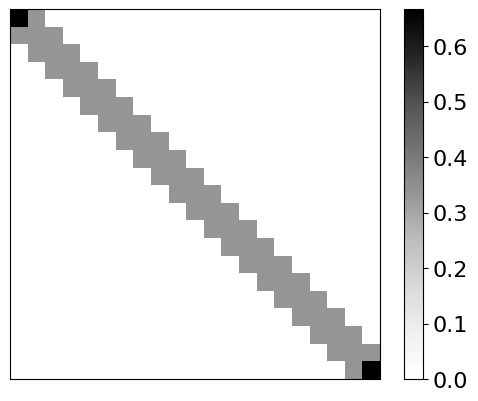

In [2]:
# Build the A matrix for the single walker

A = np.zeros((NUMBER_OF_SQUARES, NUMBER_OF_SQUARES), dtype=float)
for column in range(NUMBER_OF_SQUARES):
    for row in range(NUMBER_OF_SQUARES):
        if column == row:
            A[column, row] = 1/3
        elif column == row - 1 or column == row + 1:
            A[column, row] = 1/3

# Remember to add the boundary conditions
A[0, 0] = 2/3
A[NUMBER_OF_SQUARES - 1, NUMBER_OF_SQUARES - 1] = 2/3


# Print the A matrix with imshow, and mostly white
plt.imshow(A, cmap='Greys', interpolation='nearest')
plt.xticks([])
plt.yticks([])
plt.colorbar()
plt.show()

Playing:   0%|          | 0/10 [00:00<?, ?it/s]

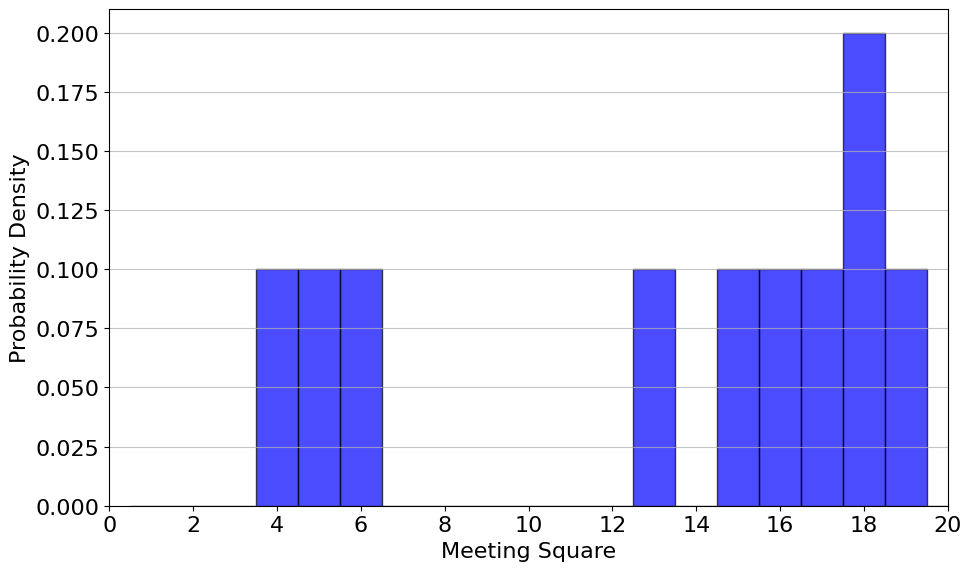

In [3]:
# Get the data for random walkers
random_walker_alice = swalkers.entities.Walker(
    name='Random Alice',
    start_position=START_POS_ALICE,
    world_dimension=NUMBER_OF_SQUARES,
    use_brain=False,
    learn=False
)
random_walker_bob = swalkers.entities.Walker(
    name='Random Bob',
    start_position=START_POS_BOB,
    world_dimension=NUMBER_OF_SQUARES,
    use_brain=False,
    learn=False
)

results = swalkers.simulation.playgames(
    walker_1=random_walker_alice,
    walker_2=random_walker_bob,
    world_dimension=NUMBER_OF_SQUARES,
    reward_function=swalkers.entities.linear_reward,
    number_of_games=NUMBER_OF_GAMES
)

meeting_squares_random = results['meeting_squares']

# Plot the meeting squares as a histogram
plt.figure(figsize=(10, 6))
plt.hist(meeting_squares_random, bins=np.arange(0.5, NUMBER_OF_SQUARES + 0.5, 1), density=True, alpha=0.7, color='blue', edgecolor='black')
plt.xlabel('Meeting Square')
plt.ylabel('Probability Density')
plt.xticks(np.arange(0, NUMBER_OF_SQUARES + 1, 2))
plt.xlim(0, NUMBER_OF_SQUARES - 1)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

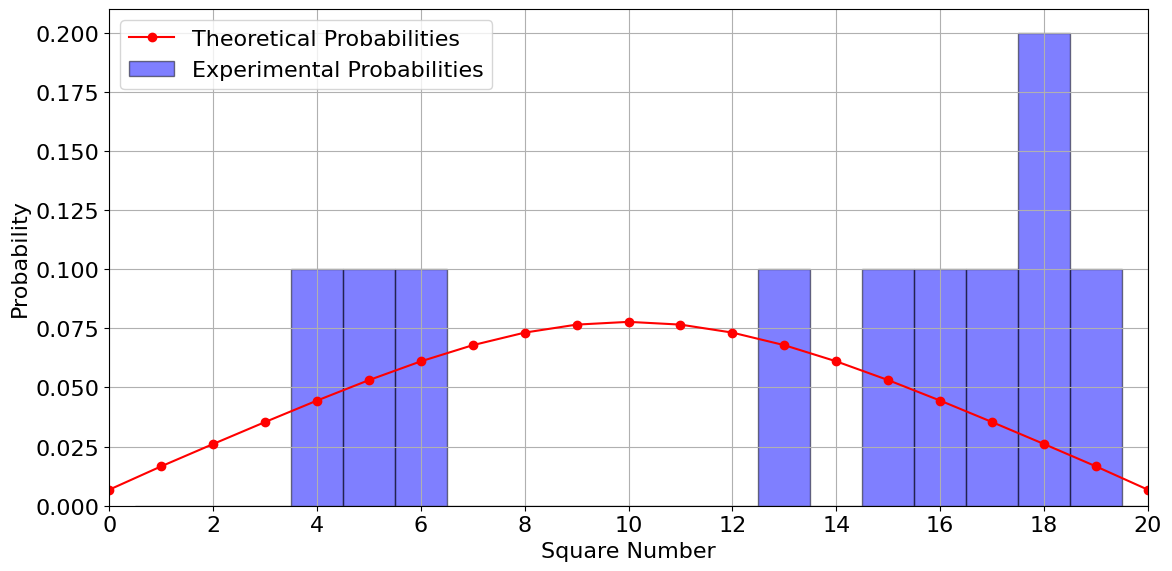

In [ ]:
# Get the theoretical cure and confront

alice_policy_tensor = random_walker_alice.get_policy_tensor()
bob_policy_tensor = random_walker_bob.get_policy_tensor()

P0 = swalkers.functions.calculate_starting_distribution_in_tensorspace(
    walker_1_start_pos=START_POS_ALICE,
    walker_2_start_pos=START_POS_BOB,
    world_dimension=NUMBER_OF_SQUARES
)

p = swalkers.functions.calculate_first_encounter_probabilities(
    starting_distribution=P0,
    walker_1_policy_tensor=alice_policy_tensor,
    walker_2_policy_tensor=bob_policy_tensor,
)

# Plot the theoretical cure and confront
plt.figure(figsize=(12, 6))
plt.plot(np.arange(NUMBER_OF_SQUARES), p, marker='o', linestyle='-', color='red', label='Theoretical Probabilities')
plt.hist(meeting_squares_random, bins=np.arange(0.5, NUMBER_OF_SQUARES + 0.5, 1), density=True, alpha=0.7, color='blue', edgecolor='black', label='Experimental Probabilities')
plt.xlabel('Square Number')
plt.ylabel('Probability')
plt.xticks(np.arange(0, NUMBER_OF_SQUARES + 1, 2))
plt.xlim(0, NUMBER_OF_SQUARES - 1)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
reward_functions = []

reward_functions.append(swalkers.entities.linear_reward)

reward_functions.append(swalkers.entities.time_dependent_linear_reward)

reward_functions.append(swalkers.entities.sinusoidal_reward)

reward_functions.append(swalkers.entities.high_frequency_sinusoidal_reward)

max_rewards = []

# Find the maximum reward for each reward function
for reward_function in reward_functions:
  max = 0
  for i in range(NUMBER_OF_SQUARES):
    alice_reward = reward_function(i, NUMBER_OF_SQUARES)[0]
    if alice_reward > max:
      max = alice_reward
  # Append the maximum reward found for this function
  max_rewards.append(max)

# Print the maximum rewards for each reward function
for i, reward_function in enumerate(reward_functions):
  print(f'Reward function {i+1}: {reward_function.__name__} - Max reward: {max_rewards[i]}')


Reward function 1: linear_reward - Max reward: 10.0
Reward function 2: time_dependent_linear_reward - Max reward: 10.0
Reward function 3: sinusoidal_reward - Max reward: 1.0
Reward function 4: high_frequency_sinusoidal_reward - Max reward: 0.9510565162951536


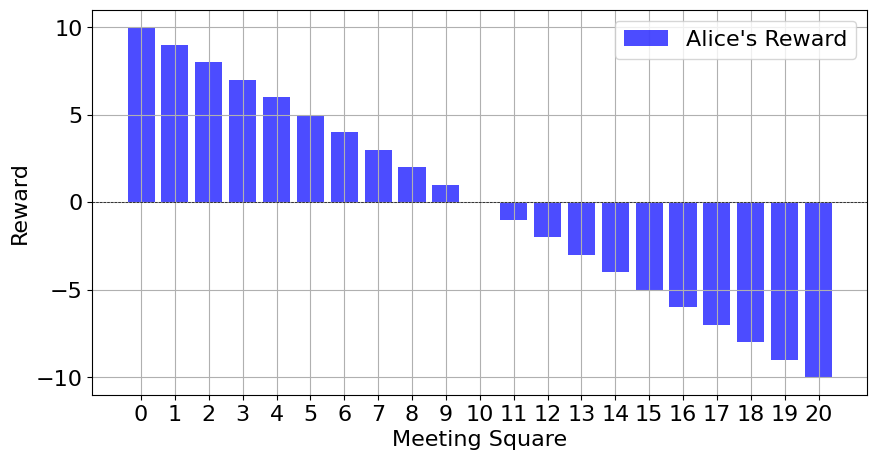

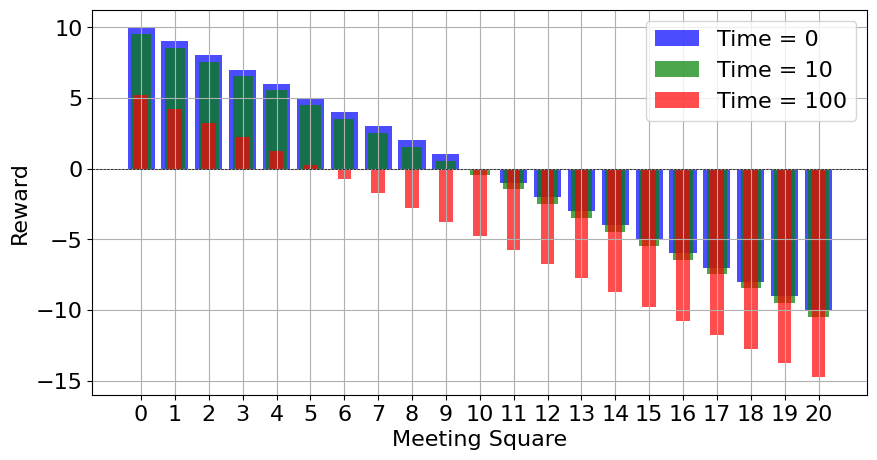

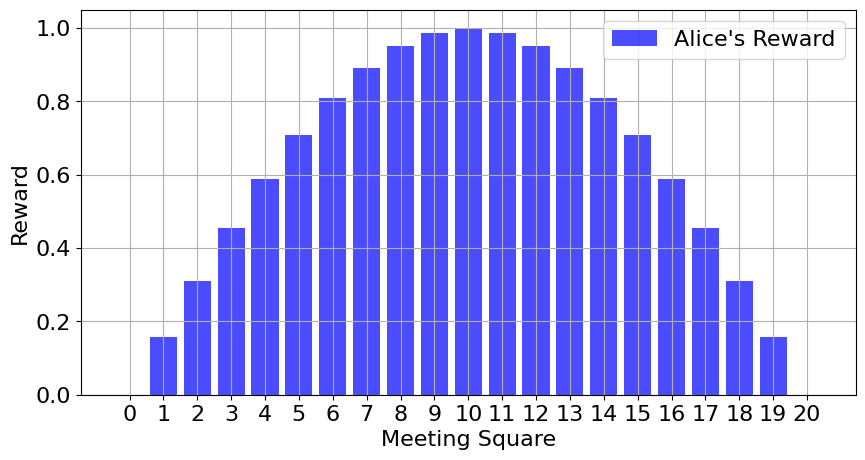

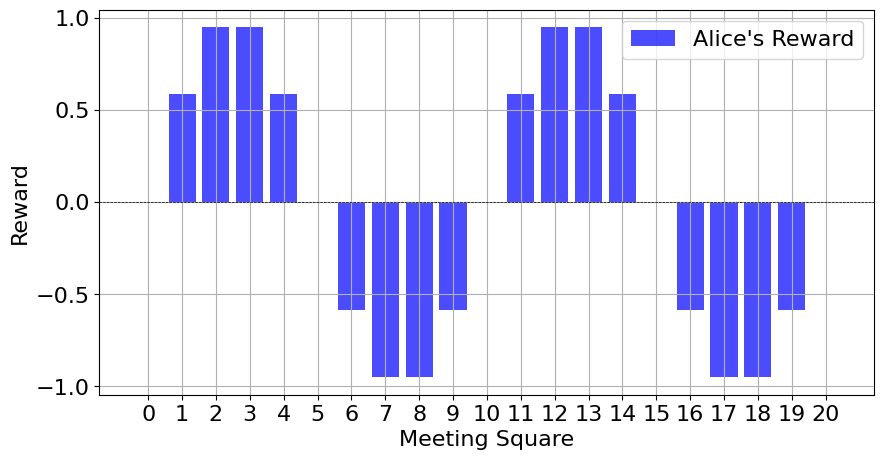

In [6]:
# Plot linear reward function

plt.figure(figsize=(10, 5))
x = np.arange(NUMBER_OF_SQUARES)
y = [reward_functions[0](i, NUMBER_OF_SQUARES)[0] for i in x]
plt.bar(x, y, color='blue', alpha=0.7, label='Alice\'s Reward')
plt.xlabel('Meeting Square')
plt.ylabel('Reward')
plt.xticks(x)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid()
plt.show()

# Plot time dependent reward function

plt.figure(figsize=(10, 5))
x = np.arange(NUMBER_OF_SQUARES)
y_0 = [reward_functions[1](i, NUMBER_OF_SQUARES, time=0)[0] for i in x]
y_10 = [reward_functions[1](i, NUMBER_OF_SQUARES, time=10)[0] for i in x]
y_100 = [reward_functions[1](i, NUMBER_OF_SQUARES, time=100)[0] for i in x]
plt.bar(x, y_0, width=0.8, color='blue', alpha=0.7, label='Time = 0')
plt.bar(x, y_10, width=0.6, color='green', alpha=0.7, label='Time = 10')
plt.bar(x, y_100, width=0.4, color='red', alpha=0.7, label='Time = 100')
plt.xlabel('Meeting Square')
plt.ylabel('Reward')
plt.xticks(x)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid()
plt.show()

# Plot sinusoidal reward function

plt.figure(figsize=(10, 5))
x = np.arange(NUMBER_OF_SQUARES)
y = [reward_functions[2](i, NUMBER_OF_SQUARES)[0] for i in x]
plt.bar(x, y, color='blue', alpha=0.7, label='Alice\'s Reward')
plt.xlabel('Meeting Square')
plt.ylabel('Reward')
plt.xticks(x)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid()
plt.show()

# Plot high frequency sinusoidal reward function

plt.figure(figsize=(10, 5))
x = np.arange(NUMBER_OF_SQUARES)
y = [reward_functions[3](i, NUMBER_OF_SQUARES)[0] for i in x]
plt.bar(x, y, color='blue', alpha=0.7, label='Alice\'s Reward')
plt.xlabel('Meeting Square')
plt.ylabel('Reward')
plt.xticks(x)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid()
plt.show()



In [7]:
# Train the walkers with different reward functions

policy_entropy_results = {}
A_entropy_results = {}
alice_reward_results = {}
trained_walkers = {}
meeting_squares_results = {}

for reward_function in reward_functions:

    # Initialize the walkers
    walker_alice = swalkers.entities.Walker(
        name='Alice',
        start_position=START_POS_ALICE,
        world_dimension=NUMBER_OF_SQUARES,
        use_brain=True,
        learn=True
    )
    walker_bob = swalkers.entities.Walker(
        name='Bob',
        start_position=START_POS_BOB,
        world_dimension=NUMBER_OF_SQUARES,
        use_brain=False,
        learn=False
    )

    results = swalkers.simulation.playgames(
        walker_alice, walker_bob, NUMBER_OF_SQUARES, reward_function, NUMBER_OF_GAMES
        )
    
    policy_entropy_results[reward_function.__name__] = results['policy_entropy_list']
    A_entropy_results[reward_function.__name__] = results['A_entropy_list']
    trained_walkers[reward_function.__name__] = {'walker_alice': walker_alice, 'walker_bob': walker_bob}
    alice_reward_results[reward_function.__name__] = results['walker_1_rewards']
    number_of_comp_prev = results['number_of_compenetrations_prevented']
    percent_affected_by_comp = number_of_comp_prev / NUMBER_OF_GAMES * 100
    meeting_squares_results[reward_function.__name__] = results['meeting_squares']

    print(f'Number of compenetrations prevented: {number_of_comp_prev}')
    print(f'Percentage of games affected by compenetrations: {percent_affected_by_comp:.2f}%')



Playing:   0%|          | 0/10 [00:00<?, ?it/s]

Number of compenetrations prevented: 0
Percentage of games affected by compenetrations: 0.00%


Playing:   0%|          | 0/10 [00:00<?, ?it/s]

Number of compenetrations prevented: 0
Percentage of games affected by compenetrations: 0.00%


Playing:   0%|          | 0/10 [00:00<?, ?it/s]

Number of compenetrations prevented: 2
Percentage of games affected by compenetrations: 20.00%


Playing:   0%|          | 0/10 [00:00<?, ?it/s]

Number of compenetrations prevented: 0
Percentage of games affected by compenetrations: 0.00%


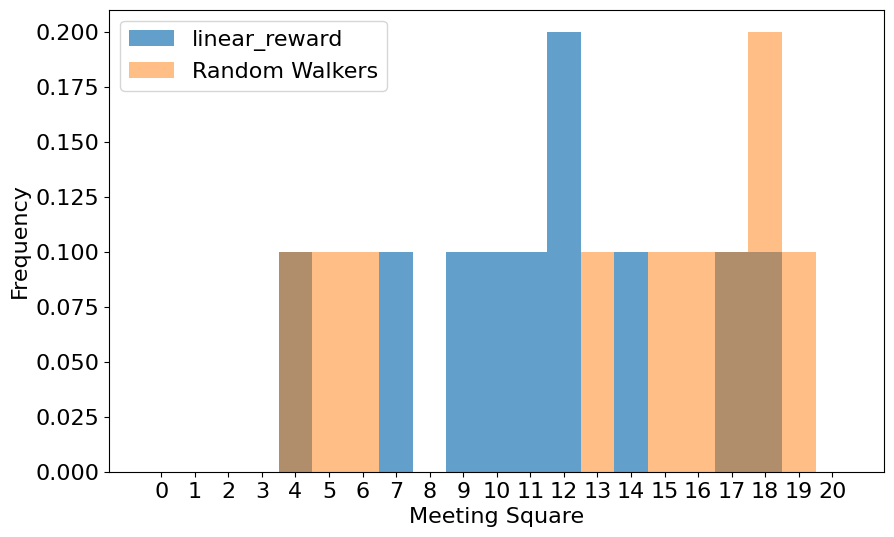

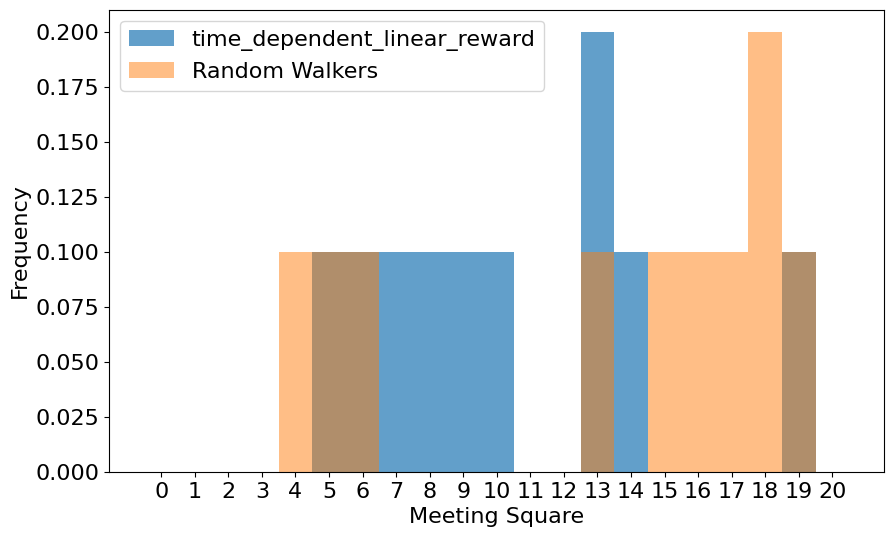

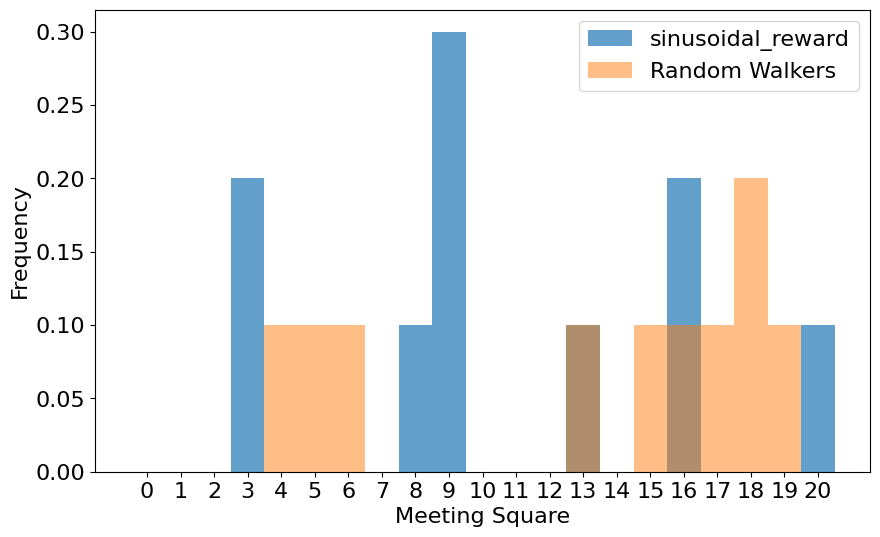

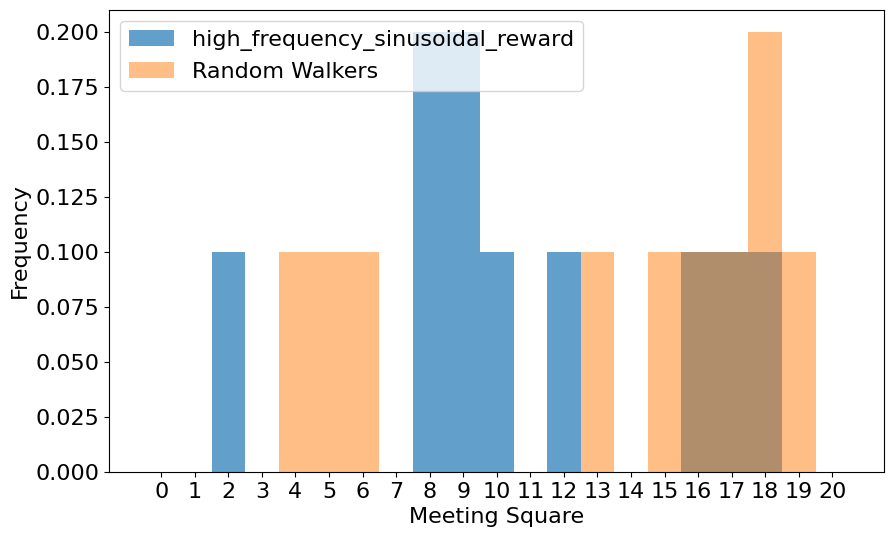

In [8]:

# Plot the meeting squares
for key, meeting_squares in meeting_squares_results.items():
    plt.figure(figsize=(10, 6))
    plt.hist(meeting_squares, bins=np.arange(NUMBER_OF_SQUARES + 1) - 0.5, density=True, alpha=0.7, label=key)
    plt.hist(meeting_squares_random, bins=np.arange(NUMBER_OF_SQUARES + 1) - 0.5, density=True, alpha=0.5, label='Random Walkers')
    plt.xlabel('Meeting Square')
    plt.ylabel('Frequency')
    plt.xticks(np.arange(NUMBER_OF_SQUARES))
    plt.legend()
    plt.show()

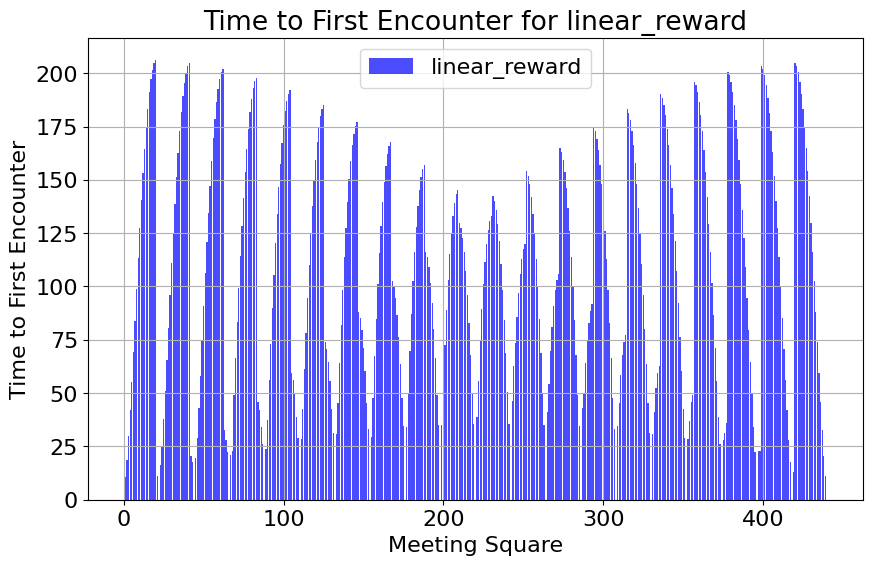

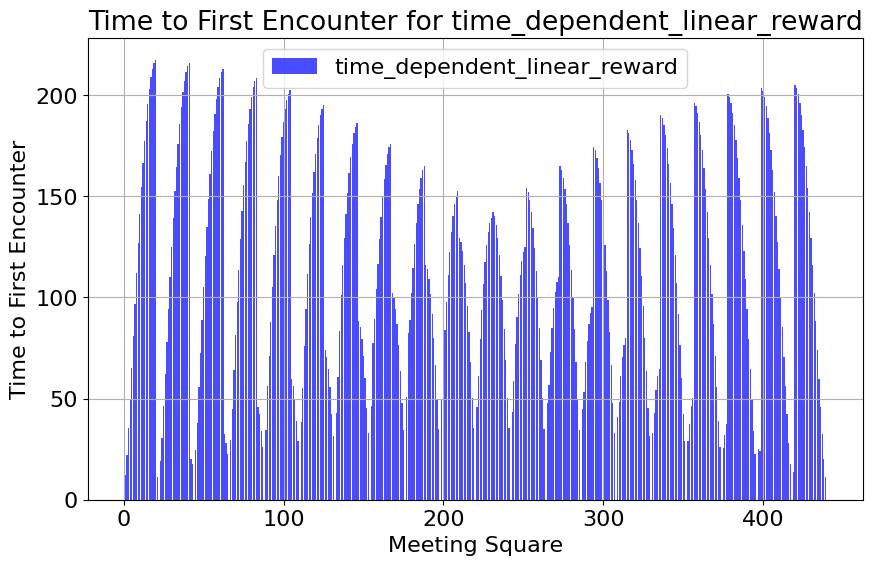

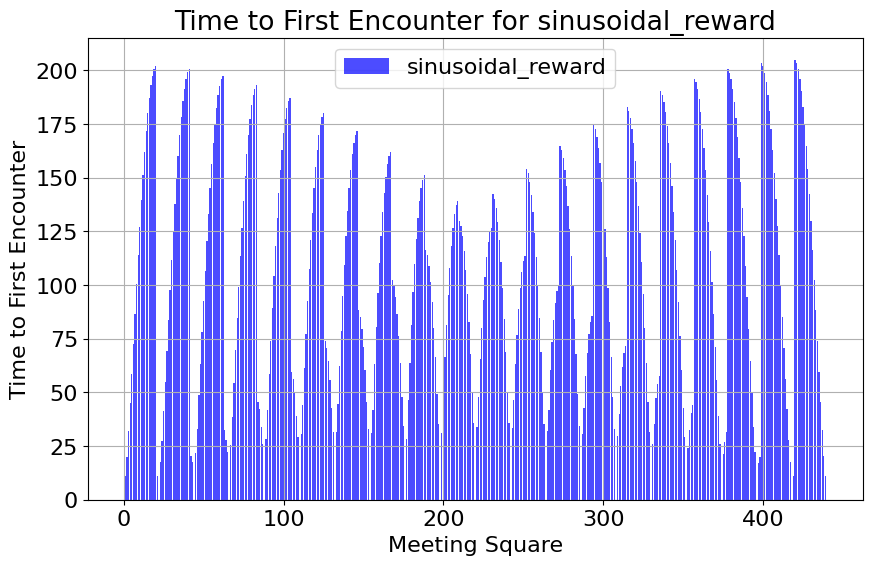

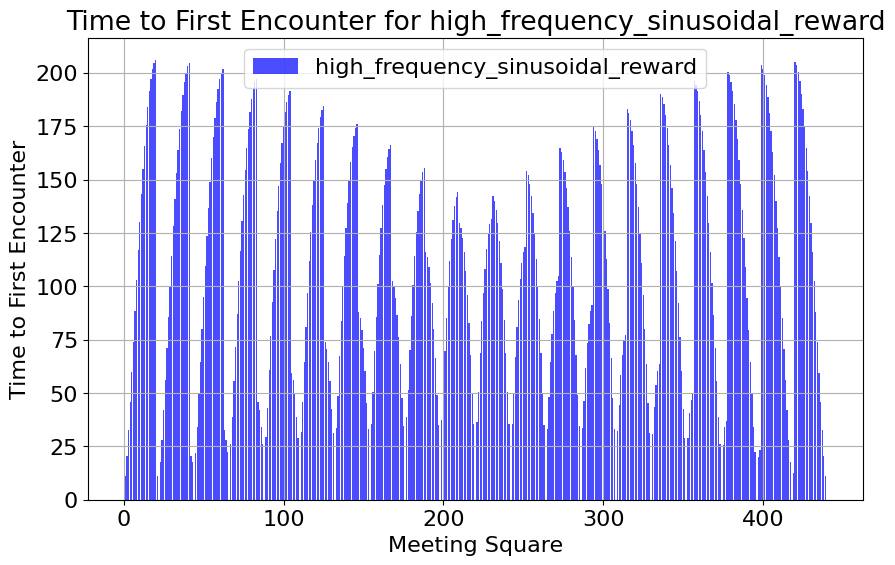

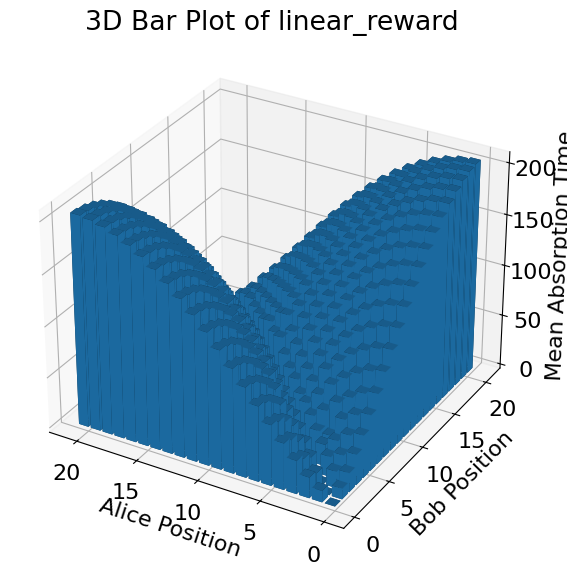

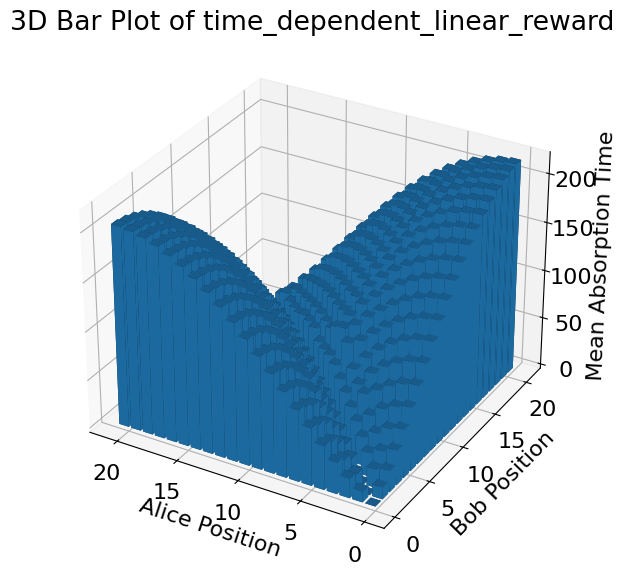

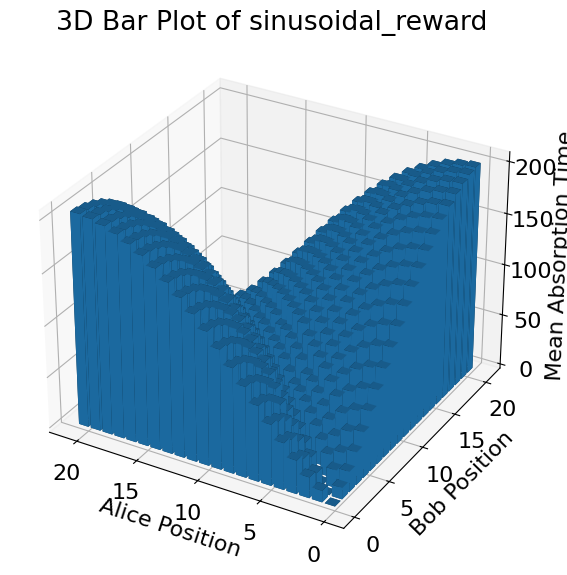

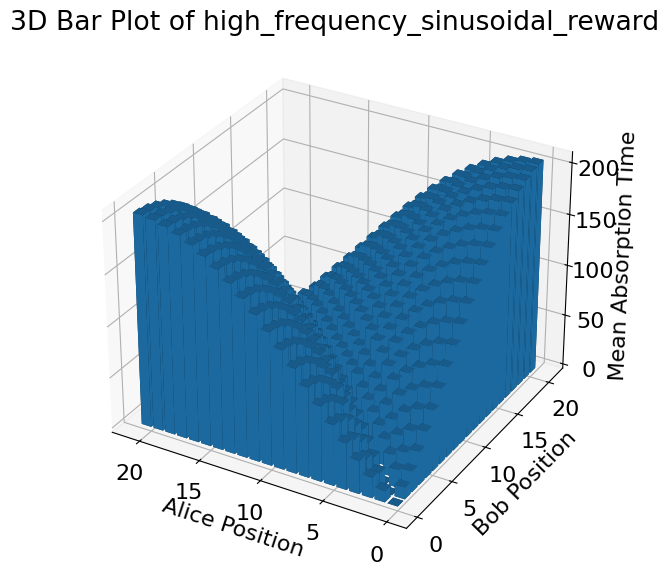

In [22]:

time_vectors = {}
time_matrices = {}

for key, couple in trained_walkers.items():
    walker_alice = couple['walker_alice']
    walker_bob = couple['walker_bob']
    
    alice_prob_tensor = walker_alice.get_policy_tensor()
    bob_prob_tensor = walker_bob.get_policy_tensor()

    swalkers.utilities.impose_reflective_boundary_conditions(alice_prob_tensor)
    swalkers.utilities.impose_reflective_boundary_conditions(bob_prob_tensor)

    A = swalkers.utilities.build_matrix_A(alice_prob_tensor, bob_prob_tensor)
    time_vector, time_matrix = swalkers.functions.calculate_first_encounter_times(A)

    time_vectors[key] = time_vector
    time_matrices[key] = time_matrix

# Plot the time vectors as a bar plot
for key, time_vector in time_vectors.items():
    plt.figure(figsize=(10, 6))
    plt.bar(np.arange(NUMBER_OF_SQUARES**2), time_vector, color='blue', alpha=0.7, label=key)
    plt.xlabel('Meeting Square')
    plt.ylabel('Time to First Encounter')
    plt.legend()
    plt.title(f'Time to First Encounter for {key}')
    plt.grid()
    plt.show()

for key, matrix in time_matrices.items():
    matrix = np.array(matrix)
    nrows, ncols = matrix.shape

    # Create a meshgrid for bar positions
    xpos, ypos = np.meshgrid(np.arange(ncols), np.arange(nrows), indexing="xy")
    xpos = xpos.flatten()
    ypos = ypos.flatten()
    zpos = np.zeros_like(xpos)  # All bars start at height 0

    # Bar dimensions
    dx = dy = 0.8  # Width and depth of bars
    dz = matrix.flatten()  # Heights of the bars

    # Plotting
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.bar3d(xpos, ypos, zpos, dx, dy, dz, shade=True)

    ax.set_title(f"3D Bar Plot of {key}")
    ax.set_xlabel('Alice Position')
    ax.set_ylabel('Bob Position')
    ax.set_zlabel('Mean Absorption Time')
    ax.invert_xaxis()  # Invert x-axis to match the original matrix orientation

    plt.tight_layout()
    plt.show()